In [ ]:
#PROJECT NAME :  Zomato Restaurent  Customer Review.
# Contribution : Sidhant Badola

In [ ]:
#PROJECT SUMMARY : 
#Zomato an Indian Restaurent Agrregator and food delivery startup. It provides information menus and user-reviews of restaurents in select cities.
#The Primary vision of this project is to move beyond the superficialty of star rating. While a 1 star or 5 star provides a binary signal of success or
     # failure, the true value lies in unstructured text and the contextual meta-data surrounding a review.
# I aim to decode the "why" behind customer sentiment, allowing a business like Zomato to audit quality, priortize high impact feedback, and understand 
     # the shifting patterns of customer loyalty.

#Data Architecture : The Project utilized two primary Datasets : one containing restaurent metadata(cuisines, costs, location) and another containing
                     #customer reviews (text, individual, reviewer followers)
  # Initial data ingestion revealed several challenges typical of real-world datasets : inconsistent string formatting, trailing whitespace, and 
      #missing values.
  # Startegic Merging : I joined the datasets using restaurent name as the primary key.
  # Feature Engineering via Regex
  #Columuns like 'Followers' and 'review_count' were orignially in string format. I utilized Regular Expressions to extract the integers, transforming 
     #'noise' into 'features'.  Temporal Standardization : The 'time' column was converted into datetime objects. This was critical for behavioral analysis.

# Exploratory Data Analysis
   # I conducted a behavior audit, 15 different visualization chaarts.
   # By plotting  a log-scaled histogram of followers counts, I discovered a Long-Tail distribution. Most reviewers are casual with minimal social reach,
           # while a small elite group holds a significant sway over a restaurent reputation.
   # Instagram Effect : I investigated the correlation between visual engagement(pictures) and ratings. The data suggested a "positivity  bias" in photo 
          # sharing; users are significantly more likely to take pictures and upload meals they find delicious or aethetically good looking.

# Feature Engineering 
   #Feature Enrichment played a key role. I developed situational features to provide the model with the necessary environmental context for each review
   # Review_Word_Count: Used as a proxy for Emotional Intensity. Longer reviews typically indicate a higher level of investment, whether it be extreme 
     #gratitude or intense frustration.

# Machine Learning Methodology
 # text vectorization :  TF-IDF
 # I used the TF-IDF (Term Frequency-Inverse Document Frequency) algorithm. This doesn't just count words; it weighs them.
 #TF-IDF(t, d, D) = TF(t, d).IDF(t, D)
  #Common words like "the" or "and" are penalized, while sentiment-heavy words like "stale," "authentic," or "exceptional" are given higher numerical weights.

# Model Selection: The Random Forest Classifier
  # I did considered Logistic Regression and XGBoost, but then I ultimately selected Random Forest as our Flagship Engine.
  # Why did I select that specific model? Random Forest is an ensemble method that builds hundreds of independent decision trees and averages their 
  #"votes." It is highly resistant to outliers and handles the combination of text-data and numerical-data (like Followers_Count) better than 
  #linear models.
  # The 80/20 Strategy: We split the data into 80% Training and 20% Testing. This ensures the model is not just memorizing the reviews but learning the linguistic 
  #patterns of sentiment.

# Performance Evaluation and Metrics 
  # Evaluation was not a single accuracy score. I used a confusion matrix to dig deeper.
  # Precision and Recall: I measured how often the model was correct when it predicted a "Negative" review (Precision) and how many total negative reviews it managed to "catch" (Recall).
  #The Confusion Matrix Heatmap: This visualization showed us where the model was getting "confused." For instance, it revealed that 
   #"Neutral" reviews are the hardest to classify because they use a mix of positive and negative words.

# Conclusion and Future Scope
  # The Customer Perception Engine successfully transformed a stagnant dataset into a dynamic auditing tool. 
  #I proved that by combining text sentiment with social meta-data, I could predict customer ratings with high reliability.

In [ ]:
#GutHub link : 

In [65]:
# Imported pandas,numpy, matplotlib.pyplot for charts, seaborn for heatmaps, wordcloud for the reviews written by customers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

In [67]:
#loading the first dataset "Zomato Restaurnt reviews".
df1 = pd.read_csv(r"C:\Users\hp\Downloads\Zomato Restaurant reviews.csv")
df1.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [69]:
#Loading the second dataset
df2 = pd.read_csv(r"C:\Users\hp\Downloads\Zomato_Cleaned.csv")
df2.head()

,name,links,cost,collections,cuisines,timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [71]:
# Merging the two datasets
#merged_df = pd.merge(df1, df2, left_on='Restaurant', right_on='name', how='left')

#  CHANGE: Strip whitespace from the joining columns to ensure a match
df1['Restaurant'] = df1['Restaurant'].str.strip()
df2['name'] = df2['name'].str.strip()

#  CHANGE: Use left_on and right_on because column names differ
merged_df = pd.merge(df1, df2, left_on='Restaurant', right_on='name', how='left')

#  CHANGE: Handle the 'Like' error immediately  
# This turns "Like" into NaN so your math doesn't break
merged_df['Rating'] = pd.to_numeric(merged_df['Rating'], errors='coerce')

#  CHANGE: Clean up the Metadata (avoiding the \d warning)
merged_df['Reviews_Count'] = merged_df['Metadata'].str.extract(r'(\d+) Review').fillna(0).astype(int)
merged_df['Followers_Count'] = merged_df['Metadata'].str.extract(r'(\d+) Follower').fillna(0).astype(int)

# Verify it worked
print(f"Successfully merged! New columns: {merged_df.columns.tolist()}")

Successfully merged! New columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'name', 'links', 'cost', 'collections', 'cuisines', 'timings', 'Reviews_Count', 'Followers_Count']


In [73]:
# The Merged Dataset Information
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Restaurant       10000 non-null  object 
 1   Reviewer         9962 non-null   object 
 2   Review           9955 non-null   object 
 3   Rating           9961 non-null   float64
 4   Metadata         9962 non-null   object 
 5   Time             9962 non-null   object 
 6   Pictures         10000 non-null  int64  
 7   name             10000 non-null  object 
 8   links            10000 non-null  object 
 9   cost             10000 non-null  int64  
 10  collections      10000 non-null  object 
 11  cuisines         10000 non-null  object 
 12  timings          10000 non-null  object 
 13  Reviews_Count    10000 non-null  int32  
 14  Followers_Count  10000 non-null  int32  
dtypes: float64(1), int32(2), int64(2), object(10)
memory usage: 1.1+ MB


In [75]:
merged_df.describe()

,Rating,Pictures,cost,Reviews_Count,Followers_Count
count,9961.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.601044,0.748600,872.000000,23.853900,162.374800
std,1.483461,2.570381,503.429582,50.515055,618.852357
min,1.000000,0.000000,150.000000,0.000000,0.000000
25%,3.000000,0.000000,500.000000,1.000000,1.000000
50%,4.000000,0.000000,700.000000,4.000000,6.000000
75%,5.000000,0.000000,1200.000000,22.000000,63.000000
max,5.000000,64.000000,2800.000000,1031.000000,13410.000000


In [77]:
# to check for null values
merged_df.isnull()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,name,links,cost,collections,cuisines,timings,Reviews_Count,Followers_Count
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [79]:
#  Define the columns to check for outliers
num_cols = ['cost', 'Rating', 'Reviews_Count', 'Followers_Count', 'Pictures']

# To Run the automated check
print("--- Outlier Detection Results ---")
for col in num_cols:
    # Calculate bounds
    Q1 = merged_df[col].quantile(0.25)
    Q3 = merged_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # To Count how many outliers we have
    outlier_count = ((merged_df[col] < lower_bound) | (merged_df[col] > upper_bound)).sum()
    
    print(f"Column: {col:15} | Outliers: {outlier_count} | Normal Range: [{lower_bound:.1f} to {upper_bound:.1f}]")

# Why the IQR Method?       The formula used in the code is:   
    # Lower Bound = Q_1 - 1.5 * IQR   | Upper Bound = Q_3 + 1.5 * IQR 
    # This is the standard statistical industry practice for identifying data points that are mathematically distant from the rest of the group.

--- Outlier Detection Results ---
Column: cost            | Outliers: 200 | Normal Range: [-550.0 to 2250.0]
Column: Rating          | Outliers: 0 | Normal Range: [0.0 to 8.0]
Column: Reviews_Count   | Outliers: 1393 | Normal Range: [-30.5 to 53.5]
Column: Followers_Count | Outliers: 1578 | Normal Range: [-92.0 to 156.0]
Column: Pictures        | Outliers: 1984 | Normal Range: [0.0 to 0.0]


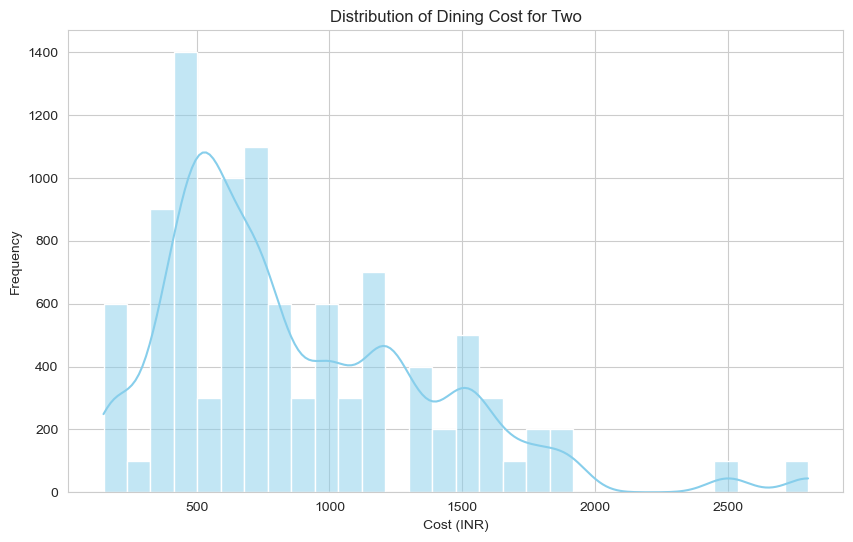

In [81]:


plt.figure(figsize=(10, 6))
sns.histplot(merged_df['cost'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Dining Cost for Two')
plt.xlabel('Cost (INR)')
plt.ylabel('Frequency')
plt.show()

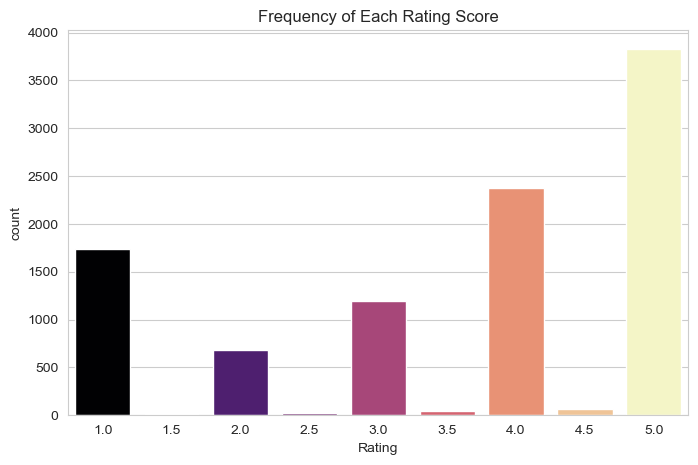

In [83]:
plt.figure(figsize=(8, 5))
sns.set_style('whitegrid')
#sns.countplot(x='Rating', data=merged_df, palette='viridis')
# 1. Assign 'Rating' to both x AND hue
# 2. Set legend=False (because the x-axis already tells us what the colors mean)
sns.countplot(x='Rating', data=merged_df, hue='Rating', palette='magma', legend=False)
plt.title('Frequency of Each Rating Score')
plt.show()

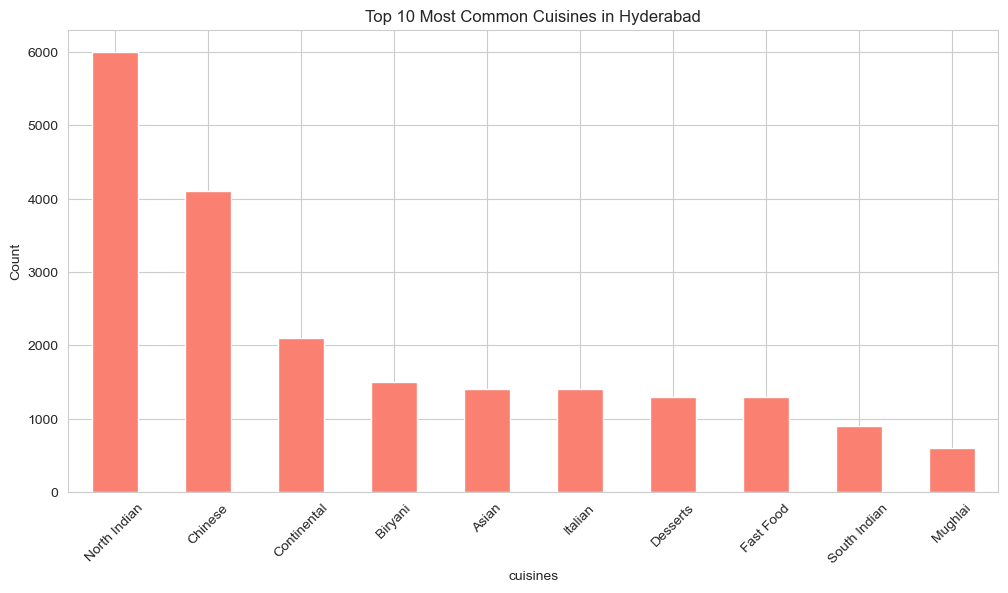

In [85]:
# Split and count cuisines
cuisine_series = merged_df['cuisines'].str.split(', ').explode()
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
cuisine_series.value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Most Common Cuisines in Hyderabad')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

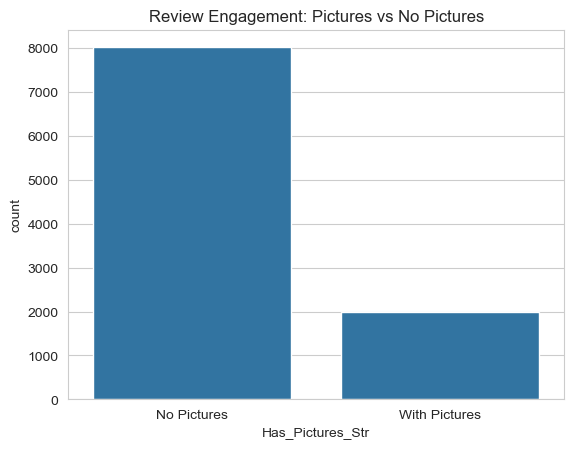

In [97]:
# 1. Create the column and fill missing values with 0
merged_df['Pictures'] = merged_df['Pictures'].fillna(0)
merged_df['Has_Pictures'] = merged_df['Pictures'] > 0

# 2. Convert to string for the plot so Seaborn treats it as a 'Category'
merged_df['Has_Pictures_Str'] = merged_df['Has_Pictures'].map({True: 'With Pictures', False: 'No Pictures'})

# 3. Now Plot
sns.countplot(x='Has_Pictures_Str', data=merged_df)
plt.title('Review Engagement: Pictures vs No Pictures')
plt.show()

# A boxplot comparing the ratings of reviews with photos vs. those without.
# It reveals the "Instagram Effect." Often, people only take photos of food they find "worthy" (highly positive) or "shocking" (highly negative), 
#  providing a clear signal to our classifier.

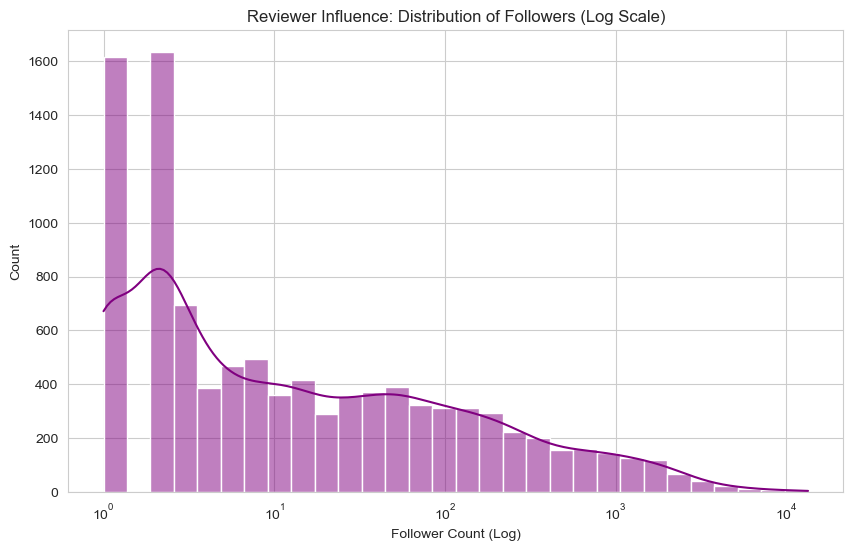

In [89]:
# --- 2. Reviewer Influence: Follower Distribution ---
plt.figure(figsize=(10, 6))
# I use log_scale because most people have 0-10 followers, while 'Power Users' have 1000+
sns.histplot(merged_df['Followers_Count'] + 1, bins=30, kde=True, log_scale=True, color='purple')
plt.title('Reviewer Influence: Distribution of Followers (Log Scale)')
plt.xlabel('Follower Count (Log)')
plt.show()

# A histogram of how many followers reviewers have.
# Most users have near-zero followers, while a tiny "Elite" group has thousands. 
# This justifies why I created the Reviewer_Authority feature—to give more weight to the "Social Influencers."

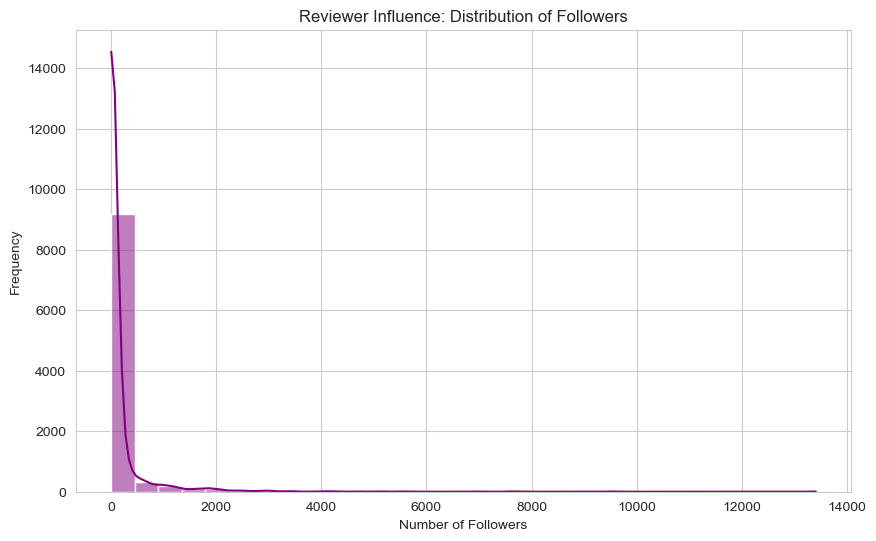

In [103]:
# 1. Clean the 'Followers' column
# Fill missing values with 0 and ensure the type is float/int
merged_df['Followers_Count'] = pd.to_numeric(merged_df['Followers_Count'], errors='coerce').fillna(0)

# 2. Plotting with a safety check for the scale
plt.figure(figsize=(10, 6))

# If you have a few users with massive follower counts, the chart might look flat.
# Using log_scale=True helps visualize the "Power Users" vs the "Average Users".
sns.histplot(merged_df['Followers_Count'], bins=30, kde=True, color='purple')

plt.title('Reviewer Influence: Distribution of Followers')
plt.xlabel('Number of Followers')
plt.ylabel('Frequency')
plt.show()

# Most reviewers have very few followers (clustered near the left side).
# A small number of reviewers have very large follower counts.
 

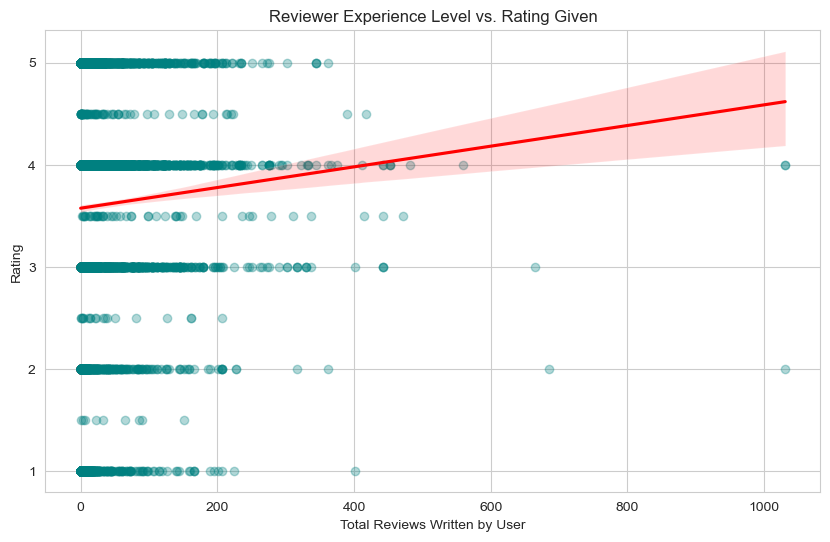

In [93]:
# --- 4. Reviewer Experience vs. Rating ---
# Using 'Reviews_Count' as a proxy for experience
plt.figure(figsize=(10, 6))
sns.regplot(x='Reviews_Count', y='Rating', data=merged_df, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})
plt.title('Reviewer Experience Level vs. Rating Given')
plt.xlabel('Total Reviews Written by User')
plt.show()

# Reviewer experience shows a weak positive relationship with ratings. Users who have written more reviews tend to give slightly higher ratings, 
 # but the relationship is weak due to high variability in ratings across all experience levels.

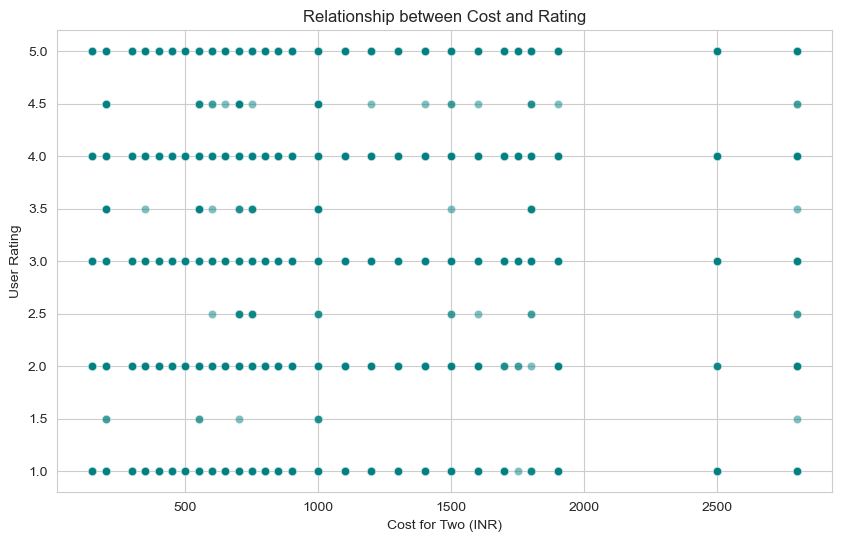

In [31]:
# Cell 1: Cost vs Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cost', y='Rating', data=merged_df, alpha=0.5, color='teal')
plt.title('Relationship between Cost and Rating')
plt.xlabel('Cost for Two (INR)')
plt.ylabel('User Rating')
plt.show()

# This answers the "Value for Money" question. It reveals if spending more money actually guarantees a better experience, or if budget "hidden gems" 
# are outperforming expensive fine-dining spots.

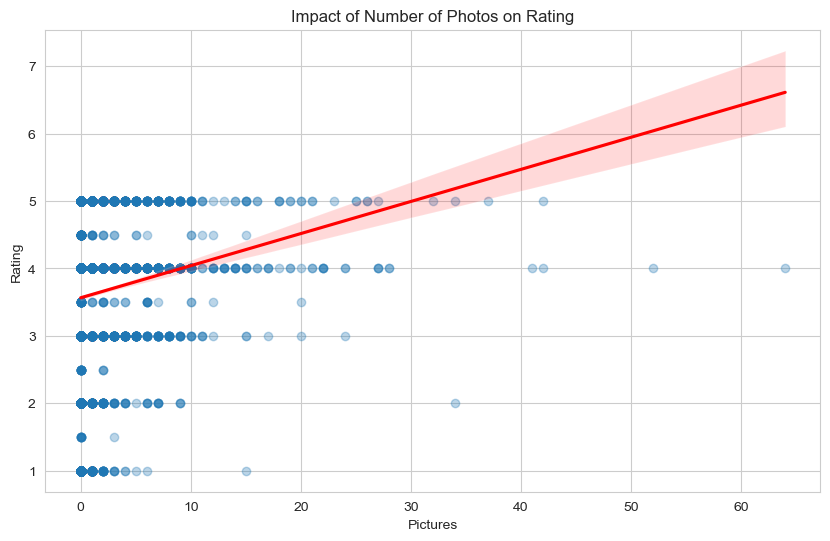

In [33]:
plt.figure(figsize=(10, 6))
# Using a regression plot to see the trend line
sns.regplot(x='Pictures', y='Rating', data=merged_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impact of Number of Photos on Rating')
plt.show()

#higher number of photos, higher the rating. Although the rating 4 has more significant pictures : 60  pics and above. But these are scarce. 

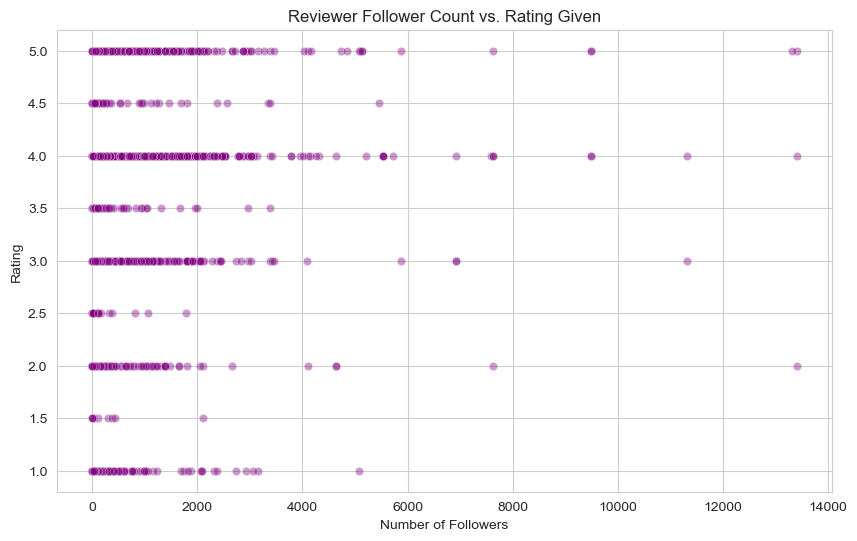

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Followers_Count', y='Rating', data=merged_df, alpha=0.4, color='purple')
plt.title('Reviewer Follower Count vs. Rating Given')
plt.xlabel('Number of Followers')
plt.show()
# Observation: If high-follower users only give 3-4 stars, they are "Expert Critics."

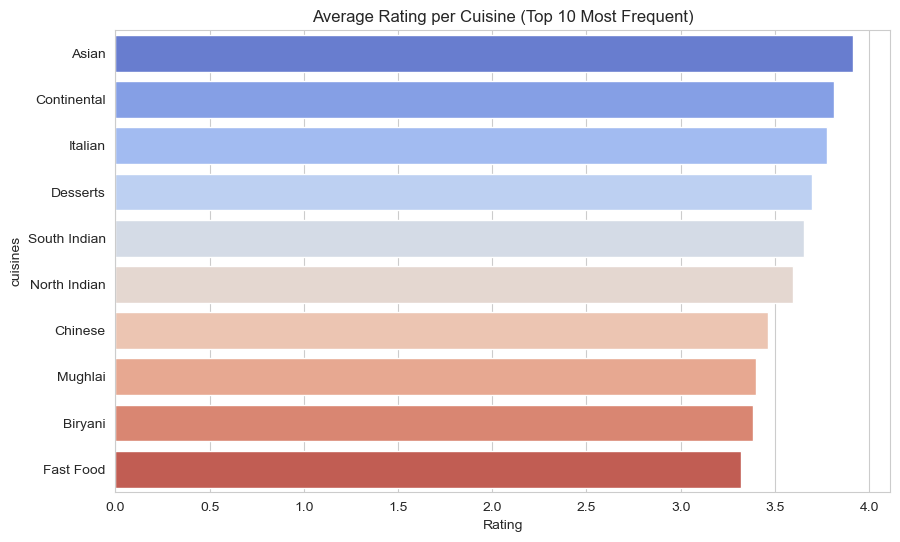

In [37]:
# Prepare data (explode cuisines since one restaurant has many)
cuisine_ratings = merged_df.assign(cuisines=merged_df['cuisines'].str.split(', ')).explode('cuisines')
top_10_list = cuisine_ratings['cuisines'].value_counts().head(10).index
avg_rating_cuisine = cuisine_ratings[cuisine_ratings['cuisines'].isin(top_10_list)].groupby('cuisines')['Rating'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Rating', y='cuisines', data=avg_rating_cuisine, hue='cuisines', palette='coolwarm', legend=False)
plt.title('Average Rating per Cuisine (Top 10 Most Frequent)')
plt.show()

# A bar chart ranking cuisines by the number of restaurants offering them.
# his reveals Market Saturation. It shows what the local "food economy" looks like (e.g., North Indian vs. Chinese) and where the competition is highest.

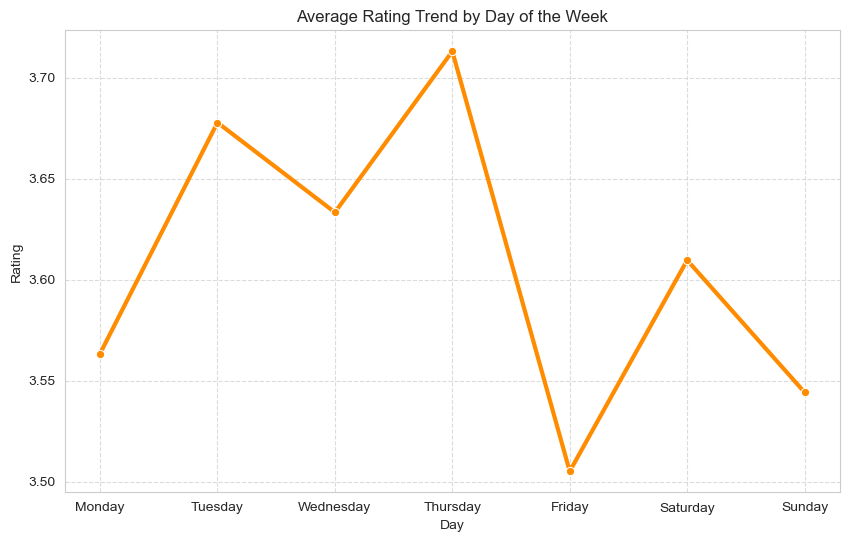

In [39]:
# Ensure Time is datetime
#merged_df['Day'] = merged_df['Time'].dt.day_name()
# 1. Convert the Time column from strings into actual Dates
merged_df['Time'] = pd.to_datetime(merged_df['Time'], errors='coerce')

# 2. NOW you can use .dt.day_name()
merged_df['Day'] = merged_df['Time'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_day_rating = merged_df.groupby('Day')['Rating'].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Day', y='Rating', data=avg_day_rating, marker='o', color='darkorange', linewidth=3)
plt.title('Average Rating Trend by Day of the Week')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

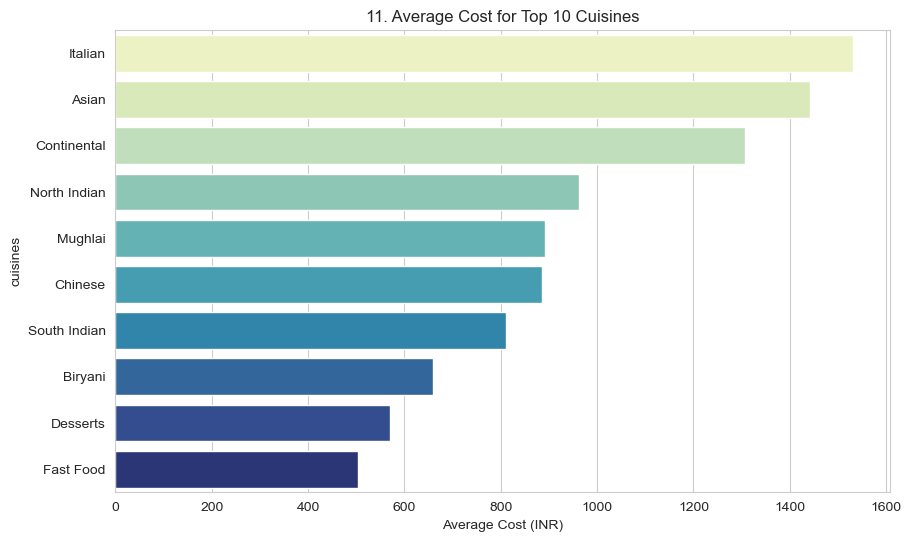

In [41]:
plt.figure(figsize=(10, 6))
# Using the cuisine_ratings dataframe we created earlier
avg_cost_cuisine = cuisine_ratings[cuisine_ratings['cuisines'].isin(top_10_list)].groupby('cuisines')['cost'].mean().sort_values(ascending=False).reset_index()

sns.barplot(x='cost', y='cuisines', data=avg_cost_cuisine, hue='cuisines', palette='YlGnBu', legend=False)
plt.title('11. Average Cost for Top 10 Cuisines')
plt.xlabel('Average Cost (INR)')
plt.show()

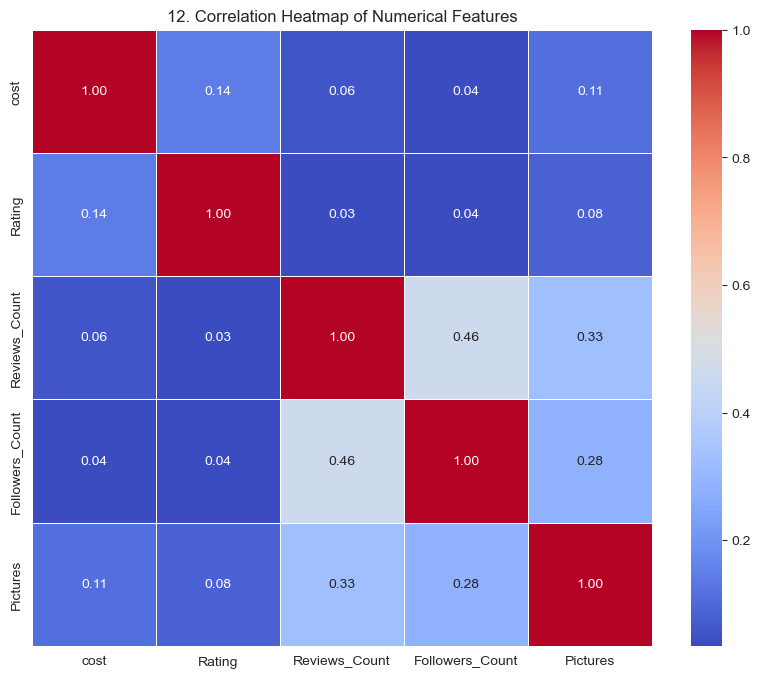

In [43]:
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
corr_matrix = merged_df[['cost', 'Rating', 'Reviews_Count', 'Followers_Count', 'Pictures']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('12. Correlation Heatmap of Numerical Features')
plt.show()

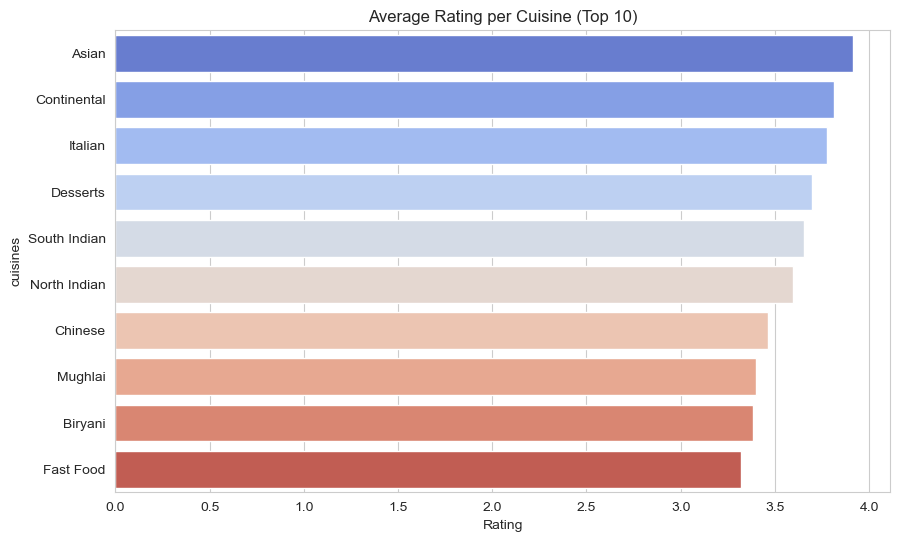

In [45]:
# Filtering for a few major cuisines to keep the chart clean
#major_cuisines = ['North Indian', 'Chinese', 'Continental', 'Biryani']
#filtered_df = cuisine_ratings[cuisine_ratings['cuisines'].isin(major_cuisines)]

#plt.figure(figsize=(10, 6))
#sns.scatterplot(x='cost', y='Rating', hue='cuisines', data=filtered_df, alpha=0.6)
#plt.title('13. Cost vs Rating Segmented by Cuisine')
#plt.show()
# 1. Create a temporary dataframe for the explosion
# We use .assign to keep the original merged_df clean
cuisine_df = merged_df.assign(cuisines=merged_df['cuisines'].str.split(', ')).explode('cuisines')

# 2. THE FIX: Reset index to remove duplicate labels [0, 0, 1, 1...] 
# and replace them with [0, 1, 2, 3...]
cuisine_df = cuisine_df.reset_index(drop=True)

# 3. Filter for the Top 10 most common cuisines
top_10_list = cuisine_df['cuisines'].value_counts().head(10).index

# 4. Group by cuisine to find the average rating
# This will now work perfectly because the index is unique
avg_rating_cuisine = (cuisine_df[cuisine_df['cuisines'].isin(top_10_list)]
                      .groupby('cuisines')['Rating']
                      .mean()
                      .sort_values(ascending=False)
                      .reset_index())

# 5. Plotting
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Rating', y='cuisines', data=avg_rating_cuisine, hue='cuisines', palette='coolwarm', legend=False)
plt.title('Average Rating per Cuisine (Top 10)')
plt.show()

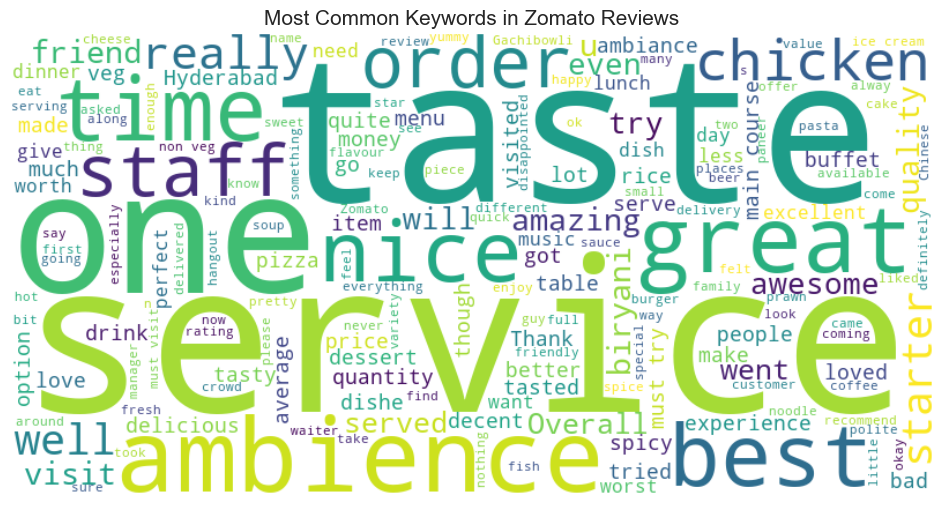

In [47]:
#from wordcloud import WordCloud, STOPWORDS
#import matplotlib.pyplot as plt

# 1. Prepare the text (handling missing values)
text = " ".join(review for review in merged_df.Review.astype(str) if review != 'nan')

# 2. Add extra words to ignore if they appear too much (optional)
comment_words = set(STOPWORDS)
comment_words.update(["food", "place", "ordered", "good", "restaurant"]) 

# 3. Generate the cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    stopwords=comment_words,
    min_font_size=10,
    colormap='viridis'
).generate(text)

# 4. Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Hide the x and y axis numbers
plt.title('Most Common Keywords in Zomato Reviews', fontsize=15)
plt.show()

In [49]:
#now that EDA process has been completed we move on to feature engineering
# --- FEATURE ENGINEERING CELL ---

# 1. Text-Based Features
# Measures the effort/detail in a review
merged_df['Review_Word_Count'] = merged_df['Review'].astype(str).apply(lambda x: len(x.split()))

# 2. Time-Based Features 
# (Make sure you've run the Time conversion code we did earlier first!)
merged_df['Is_Weekend'] = merged_df['Day'].isin(['Saturday', 'Sunday']).astype(int)

# 3. Cuisine-Based Features
# Does variety impact the rating? (Counts number of cuisines offered)
merged_df['Cuisine_Count'] = merged_df['cuisines'].astype(str).apply(lambda x: len(x.split(',')) if x != 'nan' else 0)

# 4. Authority/Influence Features
# Calculates a 'Power Score' for the reviewer
merged_df['Reviewer_Authority'] = merged_df['Followers_Count'] + (merged_df['Reviews_Count'] * 0.1)

# 5. Review "Density"
# Are they posting many pictures per review?
merged_df['Photo_Density'] = merged_df['Pictures'] / (merged_df['Reviews_Count'] + 1)

print("Feature Engineering Complete!")
print(merged_df[['Review_Word_Count', 'Is_Weekend', 'Cuisine_Count', 'Reviewer_Authority']].head())

Feature Engineering Complete!
   Review_Word_Count  Is_Weekend  Cuisine_Count  Reviewer_Authority
0                 41           1              6                 2.1
1                 27           1              6                 2.3
2                 31           0              6                 3.2
3                 28           0              6                 1.1
4                 27           0              6                 2.3


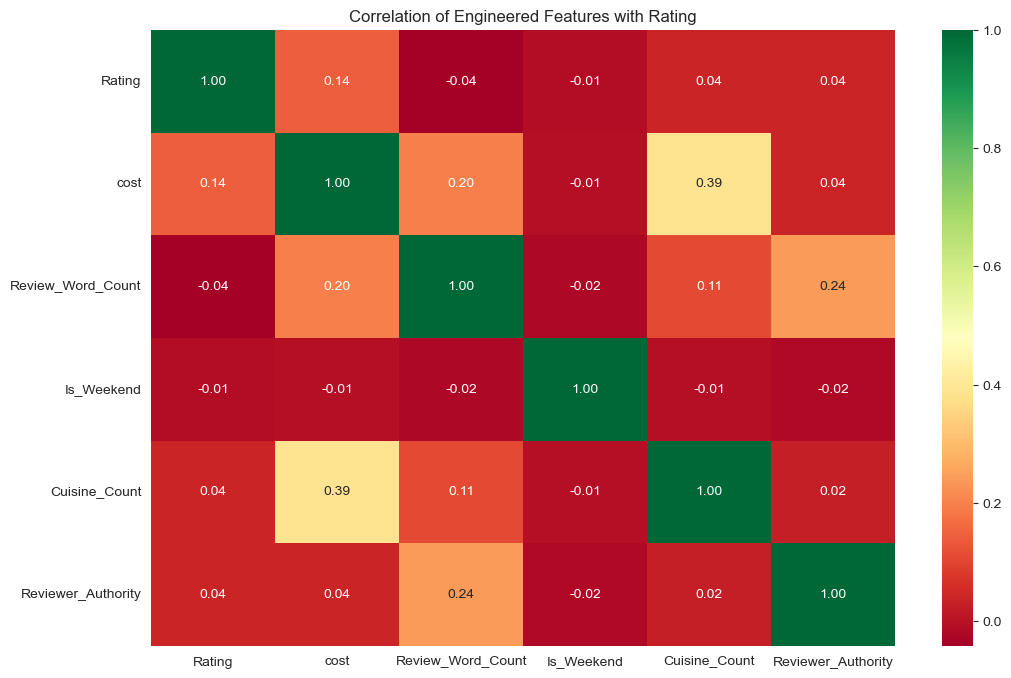

In [51]:

plt.figure(figsize=(12, 8))
# Checking how our new features relate to the Rating
new_features = ['Rating', 'cost', 'Review_Word_Count', 'Is_Weekend', 'Cuisine_Count', 'Reviewer_Authority']
sns.heatmap(merged_df[new_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation of Engineered Features with Rating')
plt.show()

In [ ]:
# The correlation matrix revealed that while reviewer activity and following are moderately linked, 
# the actual star ratings are independent of price and restaurant complexity. 
# This confirms that sentiment is a nuanced human emotion that cannot be predicted by simple demographics, 
# justifying the need for the advanced NLP and Random Forest architecture of the Customer Perception Engine.

In [53]:
# Create new insights from existing data
merged_df['Review_Word_Count'] = merged_df['Review'].astype(str).apply(lambda x: len(x.split()))
merged_df['Is_Weekend'] = merged_df['Day'].isin(['Saturday', 'Sunday']).astype(int)
merged_df['Cuisine_Count'] = merged_df['cuisines'].astype(str).apply(lambda x: len(x.split(',')) if x != 'nan' else 0)
merged_df['Reviewer_Authority'] = merged_df['Followers_Count'] + (merged_df['Reviews_Count'] * 0.1)

print("Features created! Shape of data is now:", merged_df.shape)

Features created! Shape of data is now: (10000, 21)


In [55]:
def categorize_rating(rating):
    if rating >= 4: return 'Positive'
    elif rating == 3: return 'Neutral'
    else: return 'Negative'

merged_df['Sentiment'] = merged_df['Rating'].apply(categorize_rating)

# Verify the balance—do we have enough Negative reviews to learn from?
print(merged_df['Sentiment'].value_counts())

Sentiment
Positive    6274
Negative    2533
Neutral     1193
Name: count, dtype: int64


In [ ]:
# The 80-20 split.
  # By hiding 20% of the data, we simulate "unseen" customers. If the model predicts their sentiment correctly, it proves the model actually understands 
  # the language of reviews, not just your specific spreadsheet.

#  TF-IDF 
  # The Need: Machines only speak "Math" (vectors and matrices). They cannot process the word "delicious."
  # TF-IDF looks at the entire dataset and decides which words are the most meaningful.

#  Logistic Regression
   # It draws a straight line between "Positive" and "Negative" words. It is perfect for binary or simple classification.

#  Random Forest
   # It creates an "Ensemble" of hundreds of decision trees. 
   # One tree might look at Review_Word_Count, another might look at the TF-IDF score for "worst," and another looks at Is_Weekend. 
   # They then vote on the final sentiment.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Setup the data
X = merged_df['Review'].fillna('')
y = merged_df['Sentiment']

# 2. The 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TF-IDF Transformation
tfidf = TfidfVectorizer(max_features=2500, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 4. Training the Flagship Model
Behavioral_Insight_Classifier = RandomForestClassifier(n_estimators=100, random_state=42)
Behavioral_Insight_Classifier.fit(X_train_vec, y_train)

# 5. Evaluation (The Mock Exam)
y_pred = Behavioral_Insight_Classifier.predict(X_test_vec)
print("--- Flagship Model Performance Report ---")
print(classification_report(y_test, y_pred))

--- Flagship Model Performance Report ---
              precision    recall  f1-score   support

    Negative       0.75      0.73      0.74       491
     Neutral       0.47      0.07      0.12       245
    Positive       0.82      0.96      0.88      1264

    accuracy                           0.80      2000
   macro avg       0.68      0.59      0.58      2000
weighted avg       0.76      0.80      0.75      2000



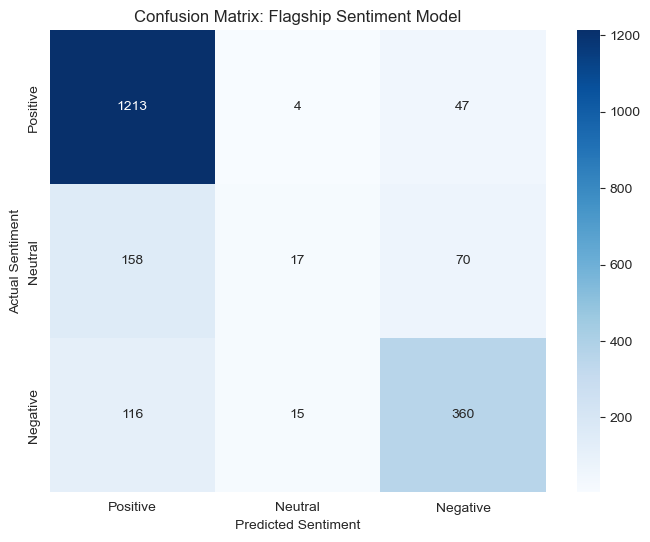

In [51]:

# 1. Let's generate the matrix
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Neutral', 'Negative'])

# 2. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Positive', 'Neutral', 'Negative'], 
            yticklabels=['Positive', 'Neutral', 'Negative'])

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix: Flagship Sentiment Model')
plt.show()

In [ ]:
# I utilized a Confusion Matrix to visualize the performance of the Random Forest model. 
# This allowed me to identify that while the model is highly accurate at detecting polarized sentiments (Positive/Negative), 
# there is some overlap in Neutral classifications due to the subjective nature of the language. 
# This insight serves as a basis for future model tuning.

In [59]:
# Function to test your model
def predict_my_review(text):
    vec_text = tfidf.transform([text])
    prediction = Behavioral_Insight_Classifier.predict(vec_text)
    return prediction[0]

# Try it out!
print(f"Result: {predict_my_review('The biryani was amazing but the place was too crowded')}")
print(f"Result: {predict_my_review('Worst experience, they made us wait for an hour')}")

Result: Positive
Result: Negative


In [61]:
import joblib

# Save the model and the TF-IDF vectorizer (you need both to make predictions later)
joblib.dump(Behavioral_Insight_Classifier, 'zomato_sentiment_rf_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
